SpectralSensitivity module loaded
Available names: ['__builtins__', '__file__', '__name__', '__nonzero__', 'blue', 'channels', 'channels_norm', 'colors', 'df', 'global_max', 'green', 'np', 'pd', 'red', 'wavelength_nm']
[1.24594214e+15 1.22621016e+15 1.20281980e+15 1.17648636e+15
 1.14784270e+15 1.11744291e+15 1.08576757e+15 1.05322985e+15
 1.02018189e+15 9.86921255e+14 9.53697107e+14 9.20716079e+14
 8.88147665e+14 8.56129141e+14 8.24770005e+14 7.94155919e+14
 7.64352221e+14 7.35406993e+14 7.07353759e+14 6.80213825e+14
 6.53998305e+14 6.28709873e+14 6.04344272e+14 5.80891593e+14
 5.58337385e+14 5.36663584e+14 5.15849309e+14 4.95871528e+14
 4.76705629e+14 4.58325882e+14 4.40705842e+14 4.23818667e+14
 4.07637394e+14 3.92135154e+14 3.77285353e+14 3.63061813e+14
 3.49438889e+14 3.36391553e+14 3.23895465e+14 3.11927020e+14
 3.00463383e+14]
[array([1.94457485e+12, 4.00153713e+12, 3.07190073e+12, 2.83772250e+12,
       2.76863308e+12, 2.53676028e+12, 5.08375847e+12, 2.08015884e+14,
       5.20

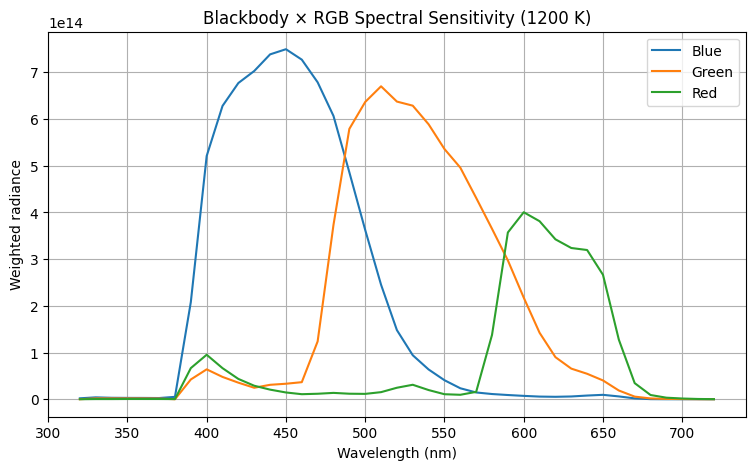

In [18]:
import numpy as np
import matplotlib.pyplot as plt
%run SpectralSensitivity.py
bb_emissivity = 1
C1= (0.59)*(10**(-16)) #W*m^2/sr
C2 = 0.01438769 # m*K
Temperature_bb = 10000
wavelength_m=wavelength_nm*(10**(-9))
bb_intensity = 2*np.pi*C1/((wavelength_m**5)*(np.exp(C2/(wavelength_m*Temperature_bb))-1))
print(bb_intensity)

lambda_function = {
    name : np.trapezoid(bb_emissivity*resp*bb_intensity, wavelength_m) for name, resp in channels_norm.items()
    }
print([bb_intensity*resp for resp in channels_norm.values()])
plt.figure(figsize=(9, 5))

for name, resp in channels_norm.items():
    plt.plot(
        wavelength_nm,
        bb_intensity * resp,
        label=name
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Weighted radiance")
plt.title("Blackbody × RGB Spectral Sensitivity (1200 K)")
plt.legend()
plt.grid(True)
plt.show()


NumPy dtype: uint16
Bits per pixel: 16
Min value: 0
Max value: 18314


TypeError: RectangleSelector.__init__() got an unexpected keyword argument 'drawtype'

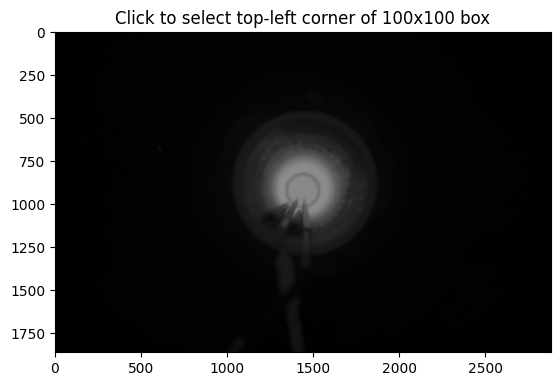

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from PIL import Image

# --- Load TIFF image WITHOUT converting bit depth ---
img = Image.open(r"C:\Users\s234031\Desktop\calib\Bayer\Bayer1000C\Bayer1000_1.tiff")
img_arr = np.array(img)

# --- Print bit depth info ---
print("NumPy dtype:", img_arr.dtype)
print("Bits per pixel:", img_arr.dtype.itemsize * 8)
print("Min value:", img_arr.min())
print("Max value:", img_arr.max())

# --- Display image ---
fig, ax = plt.subplots()
ax.imshow(img_arr, cmap="gray")
ax.set_title("Click to select top-left corner of 100x100 box")

rect_patch = None

def onselect(eclick, erelease):
    global rect_patch

    x0, y0 = int(eclick.xdata), int(eclick.ydata)

    # Clamp to image bounds
    x0 = min(x0, img_arr.shape[1] - 100)
    y0 = min(y0, img_arr.shape[0] - 100)

    region = img_arr[y0:y0+100, x0:x0+100]
    average_intensity = region.mean()

    print(f"Average intensity (100x100): {average_intensity}")

    # Remove previous rectangle
    if rect_patch:
        rect_patch.remove()

    rect_patch = plt.Rectangle(
        (x0, y0), 100, 100,
        edgecolor="red", facecolor="none", linewidth=2
    )
    ax.add_patch(rect_patch)

    ax.set_title(f"Average intensity: {average_intensity:.2f}")
    fig.canvas.draw_idle()

# Rectangle selector
rs = RectangleSelector(
    ax, onselect,
    drawtype='box',
    useblit=True,
    button=[1],
    interactive=False
)

plt.show()

[[[33 55 69]
  [33 55 69]
  [34 50 72]
  ...
  [31 36 66]
  [30 31 68]
  [30 31 68]]

 [[33 55 69]
  [33 55 69]
  [34 50 72]
  ...
  [31 36 66]
  [30 31 68]
  [30 31 68]]

 [[35 64 76]
  [35 64 76]
  [36 52 77]
  ...
  [24 43 67]
  [29 38 63]
  [29 38 63]]

 ...

 [[30 52 68]
  [30 52 68]
  [33 46 66]
  ...
  [23 51 58]
  [23 53 58]
  [23 53 58]]

 [[31 48 69]
  [31 48 69]
  [35 45 67]
  ...
  [18 55 59]
  [20 55 57]
  [20 55 57]]

 [[31 48 69]
  [31 48 69]
  [35 45 67]
  ...
  [18 55 59]
  [20 55 57]
  [20 55 57]]]
NumPy dtype: uint16
Bits per pixel: 16
Image height: 1860
Image width: 2880
Channels: 3
Min value: 0
Max value: 18314


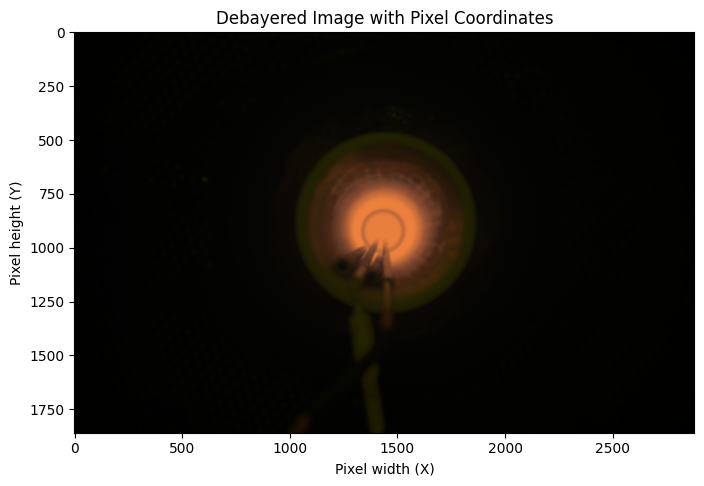

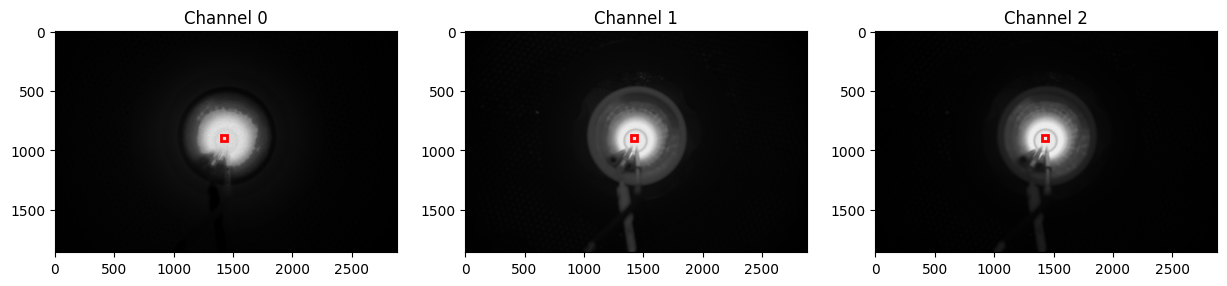

Average intensity Channel 0: 4449.6336
Average intensity Channel 1: 9155.0256
Average intensity Channel 2: 16755.5404


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

# ---- Load TIFF with tifffile (keeps native bit depth & channels) ----
img_arr = tiff.imread(r"C:\Users\s234031\Desktop\calib\Bayer\Bayer1000C\Bayer1000_1.tiff")
rgb16 = cv2.cvtColor(img_arr, cv2.COLOR_BAYER_RG2RGB)
print(rgb16)
# ---- Image info ----
print("NumPy dtype:", rgb16.dtype)
print("Bits per pixel:", rgb16.dtype.itemsize * 8)

if rgb16.ndim == 2:
    height, width = rgb16.shape
    channels = 1
elif rgb16.ndim == 3:
    height, width, channels = rgb16.shape
else:
    raise ValueError(f"Unsupported image shape: {rgb16.shape}")

print("Image height:", height)
print("Image width:", width)
print("Channels:", channels)
print("Min value:", img_arr.min())
print("Max value:", img_arr.max())

# Swap R/B
rgb16_display = rgb16[:, :, [2, 1, 0]]


# Normalize for display (16‑bit -> 8‑bit)
rgb8 = cv2.normalize(rgb16_display, None, 0, 255, cv2.NORM_MINMAX)
rgb8 = rgb8.astype(np.uint8)

# Show image with pixel coordinates
plt.figure(figsize=(8, 8))
plt.imshow(rgb8, origin="upper")  # origin=upper matches image coordinates
plt.xlabel("Pixel width (X)")
plt.ylabel("Pixel height (Y)")
plt.title("Debayered Image with Pixel Coordinates")
plt.grid(False)  # optional
plt.show()

# ---- Loop until confirmed ----
while True:
    x0 = int(input("\nEnter x coordinate (top-left, column): "))
    y0 = int(input("Enter y coordinate (top-left, row): "))

    # Clamp to bounds
    x0 = max(0, min(x0, width - 50))
    y0 = max(0, min(y0, height - 50))

    # ---- Display channels ----
    if channels == 1:
        fig, ax = plt.subplots()
        ax.imshow(rgb16,
                  cmap="gray",
                  vmin=0,
                  vmax=rgb16.max())
        ax.set_title(f"Grayscale | Box at ({x0}, {y0})")

        rect = plt.Rectangle((x0, y0), 50, 50,
                              edgecolor="red", facecolor="none", linewidth=2)
        ax.add_patch(rect)

    else:
        fig, axes = plt.subplots(1, channels, figsize=(5 * channels, 5))
        if channels == 1:
            axes = [axes]

        for c, ax in enumerate(axes):
            ax.imshow(rgb16[:, :, c],
                      cmap="gray",
                      vmin=0,
                      vmax=rgb16[:, :, c].max())
            ax.set_title(f"Channel {c}")

            rect = plt.Rectangle((x0, y0), 50, 50,
                                  edgecolor="red", facecolor="none", linewidth=2)
            ax.add_patch(rect)

    plt.show()

    # ---- Confirm ----
    confirm = input("Is this position OK? (y/n): ").lower()

    if confirm == "y":
        if channels == 1:
            region = rgb16[y0:y0+50, x0:x0+50]
            avg = region.mean()
            print(f"\nAverage pixel intensity: {avg}")
        else:
            region = rgb16[y0:y0+50, x0:x0+50, :]
            avg = region.mean(axis=(0, 1))
            for c, val in enumerate(avg):
                print(f"Average intensity Channel {c}: {val}")
                print(avg.type())
        break
    else:
        print("Position rejected — retype coordinates.")

Average intensity Channel 0: 4449.6336
<class 'numpy.ndarray'>
Average intensity Channel 1: 9155.0256
<class 'numpy.ndarray'>
Average intensity Channel 2: 16755.5404
<class 'numpy.ndarray'>
SpectralSensitivity module loaded
Available names: ['__builtins__', '__file__', '__name__', '__nonzero__', 'blue', 'channels', 'channels_norm', 'colors', 'df', 'global_max', 'green', 'np', 'pd', 'red', 'wavelength_nm']
[3.28652597e-03 1.10060313e-02 3.41753259e-02 9.90491125e-02
 2.69519727e-01 6.92150642e-01 1.68541808e+00 3.90776463e+00
 8.65956323e+00 1.84027368e+01 3.76199202e+01 7.41835028e+01
 1.41463670e+02 2.61472643e+02 4.69417525e+02 8.20113024e+02
 1.39678345e+03 2.32285523e+03 3.77740116e+03 6.01493926e+03
 9.39030777e+03 1.43893278e+04 2.16659234e+04 3.20862949e+04
 4.67806311e+04 6.72027073e+04 9.51975452e+04 1.33077119e+05
 1.83703884e+05 2.50581673e+05 3.37953306e+05 4.50904006e+05
 5.95469539e+05 7.78747793e+05 1.00901235e+06 1.29582651e+06
 1.65015600e+06 2.08447878e+06 2.61289011e

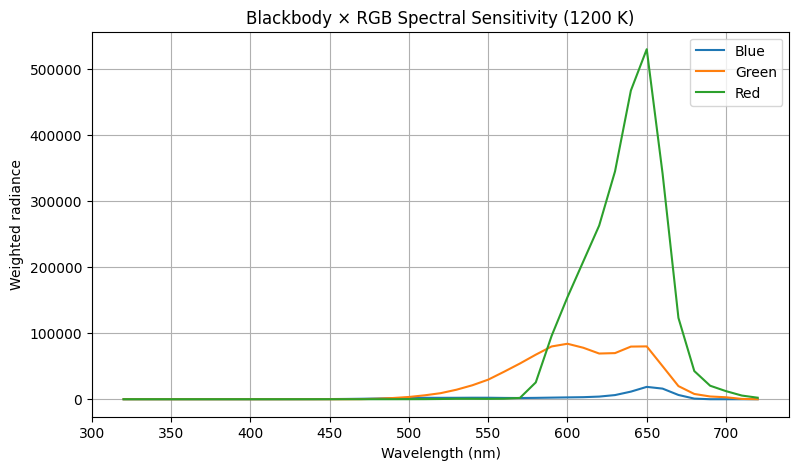

avg.shape: (3,)
{'Blue': np.float64(23407901924.374107), 'Green': np.float64(5235511484.687881), 'Red': np.float64(3174845327.747701)}


In [12]:
for c, val in enumerate(avg):
                print(f"Average intensity Channel {c}: {val}")
                print(type(avg))
import numpy as np
import matplotlib.pyplot as plt
%run SpectralSensitivity.py
bb_emissivity = 1
C1= (0.59)*(10**(-16)) #W*m^2/sr
C2 = 0.01438769 # m*K
Temperature_bb = 1000
wavelength_m=wavelength_nm*(10**(-9))
bb_intensity = 2*np.pi*C1/((wavelength_m**5)*(np.exp(C2/(wavelength_m*Temperature_bb))-1))
print(bb_intensity)

lambda_function = {
    name : np.trapezoid(bb_emissivity*resp*bb_intensity, wavelength_m) for name, resp in channels_norm.items()
    }
print([bb_intensity*resp for resp in channels_norm.values()])
plt.figure(figsize=(9, 5))

for name, resp in channels_norm.items():
    plt.plot(
        wavelength_nm,
        bb_intensity * resp,
        label=name
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Weighted radiance")
plt.title("Blackbody × RGB Spectral Sensitivity (1200 K)")
plt.legend()
plt.grid(True)
plt.show()
print("avg.shape:", np.shape(avg))
t_eff_us = 20000*(1/1000000)  # microseconds

gamma = {}

for c, name in enumerate(lambda_function):
    gamma[name] = (2*avg[c]) / ((t_eff_us**2)*lambda_function[name])
print(gamma)

Shape: (1860, 2880)
Dtype: uint16


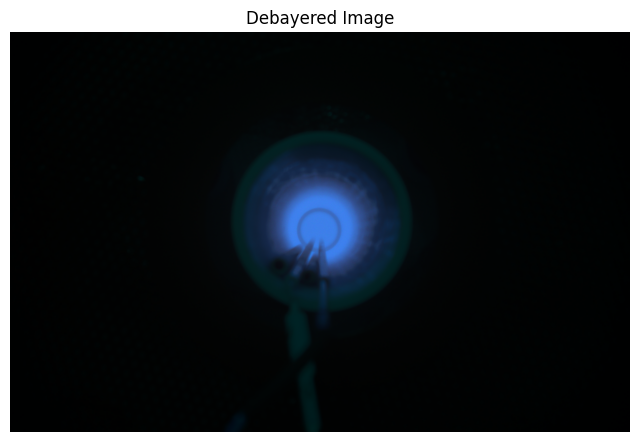

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the 16-bit Bayer TIFF (do NOT convert on read)
bayer = cv2.imread(r"C:\Users\s234031\Desktop\calib\Bayer\Bayer1000C\Bayer1000_1.tiff", cv2.IMREAD_UNCHANGED)

print("Shape:", bayer.shape)
print("Dtype:", bayer.dtype)

# IMPORTANT: choose the correct Bayer pattern for your camera
# Common options:
# COLOR_BAYER_RG2RGB
# COLOR_BAYER_BG2RGB
# COLOR_BAYER_GR2RGB
# COLOR_BAYER_GB2RGB

rgb = cv2.cvtColor(bayer, cv2.COLOR_BAYER_RG2RGB)

# Normalize for display (16-bit -> 8-bit)
rgb_8bit = cv2.normalize(rgb, None, 0, 255, cv2.NORM_MINMAX)
rgb_8bit = rgb_8bit.astype(np.uint8)

# Show image
plt.figure(figsize=(8, 8))
plt.imshow(rgb_8bit)
plt.axis("off")
plt.title("Debayered Image")
plt.show()

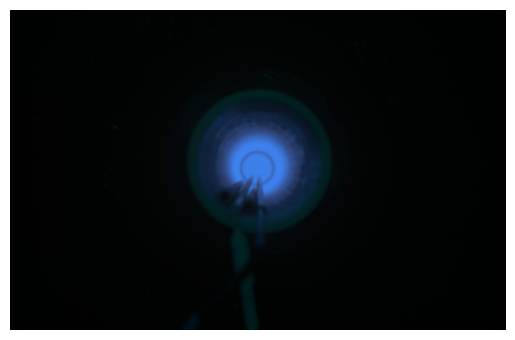

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

bayer = cv2.imread(r"C:\Users\s234031\Desktop\calib\Bayer\Bayer1000C\Bayer1000_1.tiff", cv2.IMREAD_UNCHANGED)

# Debayer directly to RGB
rgb16 = cv2.cvtColor(bayer, cv2.COLOR_BAYER_RG2RGB)

# Normalize only for display
rgb8 = cv2.normalize(rgb16, None, 0, 255, cv2.NORM_MINMAX)
rgb8 = rgb8.astype(np.uint8)

# Display (matplotlib expects RGB)
plt.imshow(rgb8)
plt.axis("off")
plt.show()

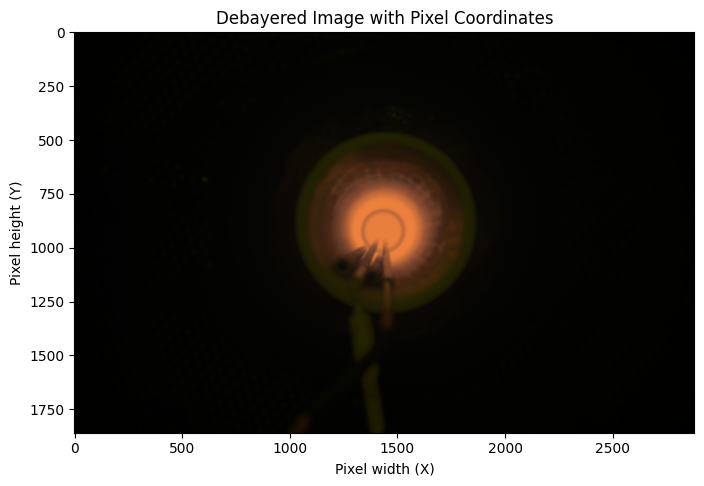

In [4]:
rgb16 = cv2.cvtColor(bayer, cv2.COLOR_BAYER_RG2RGB)

# Swap R/B
rgb16 = rgb16[:, :, [2, 1, 0]]


# Normalize for display (16‑bit -> 8‑bit)
rgb8 = cv2.normalize(rgb16, None, 0, 255, cv2.NORM_MINMAX)
rgb8 = rgb8.astype(np.uint8)

# Show image with pixel coordinates
plt.figure(figsize=(8, 8))
plt.imshow(rgb8, origin="upper")  # origin=upper matches image coordinates
plt.xlabel("Pixel width (X)")
plt.ylabel("Pixel height (Y)")
plt.title("Debayered Image with Pixel Coordinates")
plt.grid(False)  # optional
plt.show()
